# Learning Curves
Visualizza le metriche di training salvate in `training_metrics.json`.

In [ ]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

METRICS_PATH = os.path.join(
    os.path.dirname(os.getcwd()),"models", "deepseek", "supervised-learning","16-32-0.05-4bit", "training_metrics.json"
)

with open(METRICS_PATH) as f:
    data = json.load(f)

history = data["history"]
train_summary = data["train"]
print("Training summary:")
for k, v in train_summary.items():
    print(f"  {k}: {v}")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\Mattia\\Desktop\\REPOs\\vgdl-reinforcement-learning\\..\\models\\deepseek\\supervised-learning\\16-32-0.05-4bit\\training_metrics.json'

In [11]:
# Separa i log di training da quelli di evaluation
train_steps, train_loss, train_grad_norm, train_lr = [], [], [], []
eval_steps, eval_loss = [], []

for entry in history:
    if "loss" in entry:          # training log
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
        train_grad_norm.append(entry["grad_norm"])
        train_lr.append(entry["learning_rate"])
    elif "eval_loss" in entry:   # evaluation log
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

print(f"Training log points : {len(train_steps)}")
print(f"Eval log points     : {len(eval_steps)}")

Training log points : 11
Eval log points     : 5


In [12]:
# ── Ricava le epoch corrispondenti per annotare l'asse x ──────────────────────
epoch_marks = {}   # step -> epoch (arrotondato)
for entry in history:
    if "eval_loss" in entry:   # i checkpoint eval coincidono con la fine di ogni epoch
        epoch_marks[entry["step"]] = int(round(entry["epoch"]))

print("Epoch boundaries (step → epoch):", epoch_marks)

Epoch boundaries (step → epoch): {23: 1, 46: 2, 69: 3, 92: 4, 115: 5}


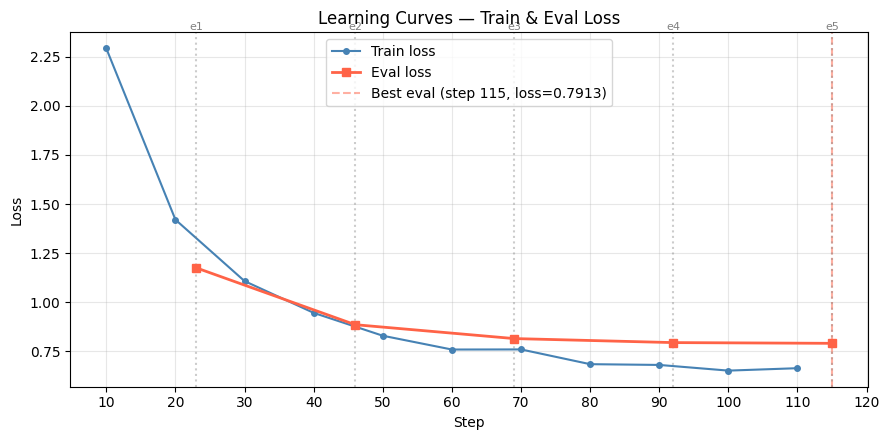

In [13]:
# ── Plot 1: Training Loss vs Eval Loss ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(train_steps, train_loss, marker="o", markersize=4,
        label="Train loss", color="steelblue")
ax.plot(eval_steps, eval_loss, marker="s", markersize=6, linewidth=2,
        label="Eval loss", color="tomato", zorder=5)

# Evidenzia il best checkpoint
best_eval_idx = eval_loss.index(min(eval_loss))
ax.axvline(eval_steps[best_eval_idx], color="tomato", linestyle="--",
           alpha=0.5, label=f"Best eval (step {eval_steps[best_eval_idx]}, "
                            f"loss={min(eval_loss):.4f})")

# Linee verticali per le epoch boundaries
for step, epoch in epoch_marks.items():
    ax.axvline(step, color="gray", linestyle=":", alpha=0.4)
    ax.text(step, ax.get_ylim()[1], f"e{epoch}",
            ha="center", va="bottom", fontsize=8, color="gray")

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Learning Curves — Train & Eval Loss")
ax.legend()
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss_curve.png", dpi=150)
plt.show()

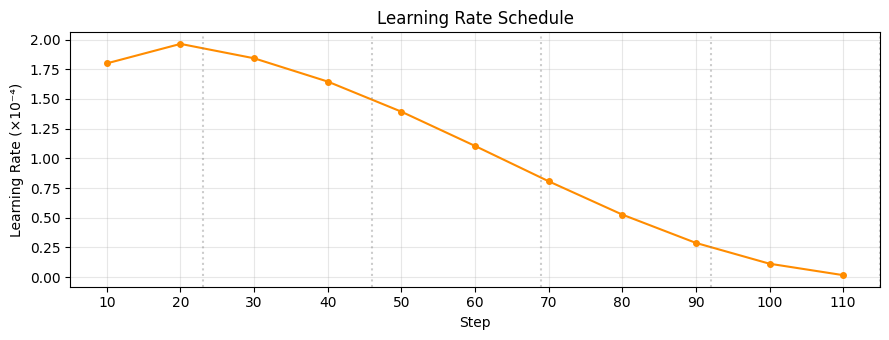

In [14]:
# ── Plot 2: Learning Rate Schedule ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))

ax.plot(train_steps, [lr * 1e4 for lr in train_lr],
        marker="o", markersize=4, color="darkorange")

for step, epoch in epoch_marks.items():
    ax.axvline(step, color="gray", linestyle=":", alpha=0.4)

ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate (×10⁻⁴)")
ax.set_title("Learning Rate Schedule")
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_rate_schedule.png", dpi=150)
plt.show()

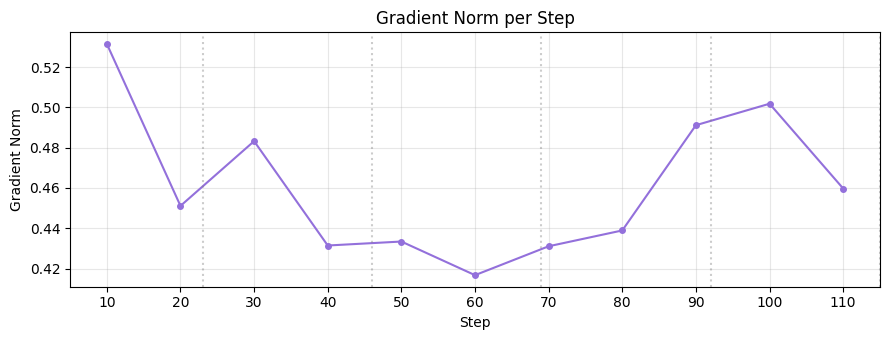

In [15]:
# ── Plot 3: Gradient Norm ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))

ax.plot(train_steps, train_grad_norm, marker="o", markersize=4, color="mediumpurple")

for step, epoch in epoch_marks.items():
    ax.axvline(step, color="gray", linestyle=":", alpha=0.4)

ax.set_xlabel("Step")
ax.set_ylabel("Gradient Norm")
ax.set_title("Gradient Norm per Step")
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("gradient_norm.png", dpi=150)
plt.show()

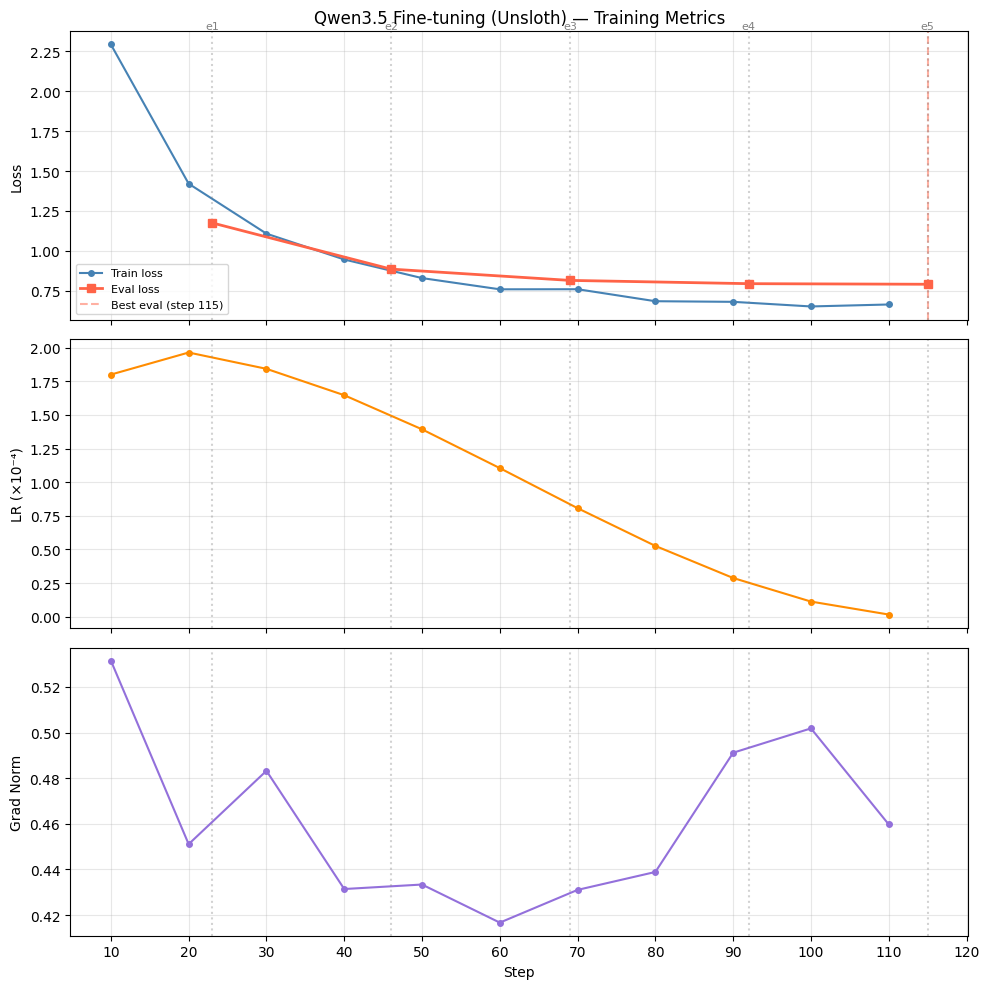

: 

In [ ]:
# ── Plot 4: Riepilogo combinato (3 subplots) ─────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# — Loss —
axes[0].plot(train_steps, train_loss, marker="o", markersize=4,
             label="Train loss", color="steelblue")
axes[0].plot(eval_steps, eval_loss, marker="s", markersize=6, linewidth=2,
             label="Eval loss", color="tomato", zorder=5)
axes[0].axvline(eval_steps[best_eval_idx], color="tomato", linestyle="--",
                alpha=0.5, label=f"Best eval (step {eval_steps[best_eval_idx]})")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)
axes[0].set_title("Qwen3.5 Fine-tuning (Unsloth) — Training Metrics")
axes[0].grid(True, alpha=0.3)

# — Learning Rate —
axes[1].plot(train_steps, [lr * 1e4 for lr in train_lr],
             marker="o", markersize=4, color="darkorange")
axes[1].set_ylabel("LR (×10⁻⁴)")
axes[1].grid(True, alpha=0.3)

# — Grad Norm —
axes[2].plot(train_steps, train_grad_norm, marker="o", markersize=4,
             color="mediumpurple")
axes[2].set_ylabel("Grad Norm")
axes[2].set_xlabel("Step")
axes[2].grid(True, alpha=0.3)

# Epoch boundaries su tutti i subplot
for step, epoch in epoch_marks.items():
    for ax in axes:
        ax.axvline(step, color="gray", linestyle=":", alpha=0.35)
    axes[0].text(step, axes[0].get_ylim()[1], f"e{epoch}",
                 ha="center", va="bottom", fontsize=8, color="gray")

axes[2].xaxis.set_major_locator(ticker.MultipleLocator(10))
plt.tight_layout()
plt.savefig("training_overview.png", dpi=150)
plt.show()